PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset as df
df= pd.read_csv('trainingpp.csv')
df.head(10)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


In [3]:
df.dtypes

text     object
label     int64
dtype: object

In [4]:
#Mapping the labels
df['label']= df['label'].map({0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'})
df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [5]:
df.dtypes

text     object
label    object
dtype: object

In [6]:
df['label'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

There are total 6 emotions in this dataset

In [7]:
df.isnull().sum()

text     0
label    0
dtype: int64

PREPROCESSING

In [8]:
#viewing no of rows and columns
n_columns= len(df.columns)
n_rows= len(df)
print("no of columns:", n_columns, "no of rows:", n_rows)

no of columns: 2 no of rows: 16000


In [9]:
#checking column names
print(df.columns)

Index(['text', 'label'], dtype='object')


In [10]:
#checking datatype of each column
df.dtypes

text     object
label    object
dtype: object

In [11]:
#checking missing values in each column in merged dataset
df.isnull().sum()

text     0
label    0
dtype: int64

In [12]:
#counting no of times emotions are used
emotion_counts = df['label'].value_counts()
emotion_counts

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [13]:
df.shape

(16000, 2)

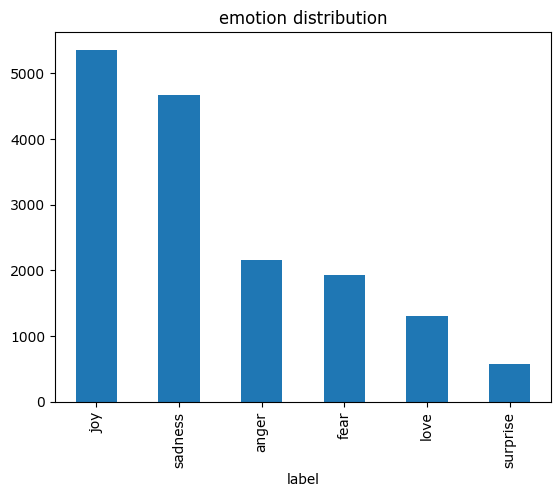

In [14]:
#plotting a barplot
emotion_counts.plot(kind= 'bar')
plt.xlabel= ("kind of emotions")
plt.ylabel= ("no of emotions")
plt.title("emotion distribution")
plt.show()

In [15]:
#Reviewing the text
print(df.head(10))

                                                text     label
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love


In [16]:
df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [17]:
#Cleaning and preprocessing the texts
import re

def clean_text(text):
    text = text.lower()  # lowercasing the text
    text = re.sub(r'http\S+|www\S+', '', text)  # removing URLs
    text = re.sub(r'@\w+', '', text)  # removing mentions
    text = re.sub(r'#\w+', '', text)  # removing hashtags
    text = re.sub(r'[^a-z\s]', '', text)  # keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # removing extra spaces
    return text

df['text'] = df['text'].apply(clean_text)
df.head(20)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [18]:
#Removing duplicates
df.drop_duplicates(subset='text', inplace=True)
df.head(20)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [19]:
#Removing stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arora\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,label
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger


Stopwords like in, a, is, etc are removed to make the text short and crisp for the model to understand

In [20]:
#lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
df['label'] = df['label'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df.head()


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arora\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\arora\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,label
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger


In [21]:
# Saving preprocessed dataset to CSV to later use it for next steps
df.to_csv("merged_dataset.csv", index=False)

In [22]:
df.head(10)

,text,label
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger
5,ive feeling little burdened lately wasnt sure,sadness
6,ive taking milligrams times recommended amount...,surprise
7,feel confused life teenager jaded year old man,fear
8,petronas years feel petronas performed well ma...,joy
9,feel romantic,love
